# Instruction following

Instruction following measures whether a model does what a prompt asks, e.g. avoiding a set of forbidden words, highlighting a number of sections, or ending with a fixed phrase. This notebook studies how post-hoc attention steering ([PASTA](https://arxiv.org/abs/2311.02262)) affects instruction following on single-instruction prompts from [Split-IFEval](https://huggingface.co/datasets/ibm-research/Split-IFEval). PASTA has two stages: 1) a one-time model profiling stage that identifies which attention heads respond to steering, and 2) inference-time reweighting of those heads onto chosen input spans. Here those spans are the instruction lines of each prompt. We first profile the heads on a slice of the dataset disjoint from the evaluation set, then sweep the steering strength (`alpha`) over the profiled head set and study the trade-off between strict instruction following and general response quality, measured with a reward model.


### Runtime estimate

> **Estimated time:** 2-3 hours on the first run (head profiling plus the sweep); re-runs load the cached `.spipe` and skip profiling  
> **Device:** NVIDIA H100 GPU (80GB VRAM)

Times are approximate and vary with the profiling settings, the number of sweep points, samples, generated tokens, and trials. The profiling stage steers each (layer, head) pair one at a time over a task-agnostic set of prompts and keeps the best scoring heads. The evaluation stage is 5 configurations (the baseline and four `alpha` values) times 10 trials times 48 samples at 128 new tokens, batched 8 at a time, plus one reward-model forward per response. Note that the reward model shares the GPU with the pipeline under evaluation.

## Setup

In [1]:
import gc
import importlib.util
import sys
from pathlib import Path

import nltk
import numpy as np
import pandas as pd
import torch
import transformers
from matplotlib import gridspec
from matplotlib import pyplot as plt

from steerability.algorithms.core.internals import text_config
from steerability.algorithms.core.specs import ControlSpec
from steerability.algorithms.core.steering_pipeline import SteeringPipeline
from steerability.algorithms.state_control.pasta.control import PASTA
from steerability.algorithms.state_control.pasta.profiling import HeadProfile, HeadProfileResult
from steerability.evaluation.plotting import (
    apply_plot_style,
    plot_metric_heatmap,
    plot_sensitivity,
    plot_tradeoff,
)
from steerability.evaluation.provider import ProviderOptions
from steerability.evaluation.runner import SteeringEval, summarize_runs
from steerability.evaluation.suite import InspectSuite
from steerability.spipe import SPipe
from steerability.utils.verbosity import quiet_third_party

quiet_third_party()

try:
    nltk.download("punkt_tab", quiet=True)
except Exception:
    pass

_cwd = Path.cwd()
NOTEBOOK_DIR = _cwd if _cwd.name == "instruction_following" else _cwd / "examples/notebooks/studies/instruction_following"
NOTEBOOK_DIR = NOTEBOOK_DIR.resolve()

## Defining the evaluation task

The evaluation task lives in `task.py` next to this notebook, which `InspectSuite` runs through the reference `task.py@instruction_following`.

In that file, the task selects a balanced set of single-instruction prompts (a fixed number per instruction type), delivers each prompt's instruction lines to PASTA through the per-sample runtime kwargs, and scores every response two ways: `instruction_checker()` runs the strict and loose IFEval checkers, and `reward_score()` scores the response with a reward model. The solver is `runtime_kwargs_solver()`, which performs the generation and delivers each sample's runtime kwargs. We load the module here to reuse its helpers for displaying the evaluation set. We also register it in `sys.modules` under the name `task`, so the profiling scorer resolves by name when the cached `.spipe` is loaded with `allow_code=True`.

In [2]:
TASK_FILE = NOTEBOOK_DIR / "task.py"
TASK_REFERENCE = f"{TASK_FILE}@instruction_following"

_task_spec = importlib.util.spec_from_file_location("task", TASK_FILE)
_task_module = importlib.util.module_from_spec(_task_spec)
_task_spec.loader.exec_module(_task_module)
sys.modules["task"] = _task_module
SPLIT_IFEVAL_PATH = _task_module.SPLIT_IFEVAL_PATH
DEFAULT_INSTRUCTION_TYPES = _task_module.DEFAULT_INSTRUCTION_TYPES
load_records = _task_module.load_records
select_records = _task_module.select_records
clean_kwargs = _task_module.clean_kwargs
profile_records = _task_module.profile_records
to_profile_row = _task_module.to_profile_row
strict_follow = _task_module.strict_follow

The configuration below sets the model, the four instruction types, the evaluation size, the profiling settings, and the PASTA sweep points. The profiling stage scores each head on a task-agnostic set of prompts (the Split-IFEval instruction types the evaluation does not use), steers one head at a time at a fixed strength `PROFILE_ALPHA`, and keeps the `HEAD_TOP_K` heads with the largest paired lift over the unsteered baseline. A two-stage screen scores every head on `SCREEN_ROWS` rows first and rescores only the top `SCREEN_KEEP` on the full set. The paper recommends steering a moderate number of heads (roughly 50 to 150) and fixes its scaling coefficient at 0.01. The toolkit parameterizes `alpha` as the emphasis factor, i.e., the reciprocal of the paper's coefficient, so `PROFILE_ALPHA = 100` is the paper's operating point and `ALPHAS` spans coefficients of 0.04 down to 0.005 around it. `METRICS` names the two reported metrics, the strict prompt-level accuracy from the IFEval checker and the mean reward score.

In [3]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
INSTRUCTION_TYPES = list(DEFAULT_INSTRUCTION_TYPES)
PER_TYPE = 12
SAMPLE_SEED = 123
ALPHAS = [25.0, 50.0, 100.0, 200.0]
NUM_TRIALS = 10
SEED = 7
TEMPERATURE = 0.7
MAX_TOKENS = 128
REWARD_MODEL = "OpenAssistant/reward-model-deberta-v3-large-v2"
REWARD_MAX_LENGTH = 1024
SAVE_DIR = NOTEBOOK_DIR / "runs" / "instruction_following_profiled_b32"

MODEL_DTYPE = torch.bfloat16
HF_MODEL_KWARGS = {"attn_implementation": "eager", "dtype": MODEL_DTYPE}
EVAL_BATCH = 32

PROFILE_ALPHA = 100.0
HEAD_TOP_K = 48
SCREEN_ROWS = 64
SCREEN_KEEP = 96
PROFILE_BATCH = 32
PROFILE_SEED = 456
PROFILE_DIR = NOTEBOOK_DIR / "artifacts"
PROFILE_SPIPE = PROFILE_DIR / "pasta_profiled.spipe"
PROFILE_JSON = PROFILE_DIR / "head_profile.json"

METRICS = {
    "strict_prompt_acc": "instruction_checker/prompt_level_strict",
    "mean_reward": "reward_score/mean",
}
SWEPT_PARAMS = {"alpha": ("PASTA", "alpha")}

## The evaluation set

The task builds its dataset by selecting single-instruction prompts from Split-IFEval, keeping a fixed number per instruction type so the four types are balanced. The selection is a deterministic function of the instruction types, the per-type count, and the sample seed, so it is identical across arms and trials. We reproduce it here from the same arguments the task uses, to show the exact prompts the evaluation will run on. Note that `select_records` is pure over a list of records, so calling it here rebuilds the same set the task builds internally.

In [4]:
selected = select_records(load_records(), INSTRUCTION_TYPES, PER_TYPE, SAMPLE_SEED)
group_sizes = pd.Series([record["instruction_id_list"][0] for record in selected]).value_counts()
group_sizes

keywords:forbidden_words                         12
detectable_format:number_highlighted_sections    12
language:response_language                       12
startend:end_checker                             12
Name: count, dtype: int64

In [5]:
evaluation_set = pd.DataFrame([
    {
        "key": record["key"],
        "instruction_id": record["instruction_id_list"][0],
        "prompt": record["prompt"][:80] + ("..." if len(record["prompt"]) > 80 else ""),
    }
    for record in selected
])
evaluation_set

,key,instruction_id,prompt
0,3081,keywords:forbidden_words,Can you re-create a story from a fictional new...
1,301,keywords:forbidden_words,Explain to me how to ride a bike like I am a k...
2,2207,keywords:forbidden_words,Here is the summary of a research paper on the...
3,2811,keywords:forbidden_words,Can you write a rap that doesn't include the k...
4,1147,keywords:forbidden_words,Rewrite the following statement to make it sou...
5,1629,keywords:forbidden_words,"Make the sentence ""The bus arrived at the stat..."
6,3401,keywords:forbidden_words,"Can you give me a zany, bullet point TLDR of t..."
7,2828,keywords:forbidden_words,Write a parody of 'ars poetica'.\n\nYour respo...
8,1675,keywords:forbidden_words,"Can you provide a translation for ""今天天气很好"" in ..."
9,2432,keywords:forbidden_words,My best friend drowned yesterday and I'm so sa...


## Profiling the attention heads

PASTA steers a small subset of attention heads. The paper reports that steering all heads performs worse than the unsteered baseline and that steering performance varies substantially across layers and across heads within a layer, so the effective heads are identified by a one-time profiling pass. The profiling procedure is part of the PASTA control, where `head_config=HeadProfile(...)` steers each candidate head on its own on the profiling rows, scores each response with the strict IFEval checker, and ranks the heads by the paired lift of their follow score over the unsteered baseline. The selected heads become the control's dict head map (with the resolution is available on the steered control as `head_profile`).

The profiling set uses single-instruction prompts from instruction types excluded from evaluation, which keeps the two sets disjoint while allowing profiling to use more examples than a per-type evaluation slice. Heads are ranked by paired lift rather than raw follow rate because paired lift provides a standard error for each head. Ties are broken deterministically, and we select only heads that outperform the baseline. Profiling uses greedy decoding (`do_sample=False`), so each head requires only one generation pass.

We build the profiling rows by applying `to_profile_row` to `profile_records`. It selects single-instruction records whose type is not in `INSTRUCTION_TYPES`. Each row contains the prompt, the instruction lines as the `substrings` runtime kwarg for PASTA, and the instruction id as the group. Profiling uses `strict_follow` from `task.py`, which runs the strict IFEval checker. The scorer has a module-level name so the resolved profile can be frozen into a `.spipe`. `HeadProfile.budget` reports the exact number of rollouts before any model is loaded.

In [6]:
records = load_records()
rows = [to_profile_row(record) for record in profile_records(records, INSTRUCTION_TYPES)]

profile = HeadProfile(
    rows=rows,
    scorer=strict_follow,
    alpha=PROFILE_ALPHA,
    num_heads=HEAD_TOP_K,
    screen_rows=SCREEN_ROWS,
    screen_keep=SCREEN_KEEP,
    gen_kwargs={"max_new_tokens": MAX_TOKENS, "do_sample": False},
    batch_size=PROFILE_BATCH,
    seed=PROFILE_SEED,
)

model_config = text_config(transformers.AutoConfig.from_pretrained(MODEL_NAME))
NUM_LAYERS = model_config.num_hidden_layers
NUM_HEADS = model_config.num_attention_heads

pd.Series({
    "profiling prompts": len(rows),
    "layers": NUM_LAYERS,
    "heads per layer": NUM_HEADS,
    **{f"rollouts.{key}": value for key, value in profile.budget(NUM_LAYERS, NUM_HEADS).items()},
}).to_frame("count")

,count
profiling prompts,233
layers,28
heads per layer,12
rollouts.candidates,336
rollouts.baseline,233
rollouts.stage_1,21504
rollouts.stage_2,22368
rollouts.total,44105


The PASTA control uses the profile as its `head_config`. The pipeline resolves that profile through its session, so profiling runs on the same model that the pipeline loads with `attn_implementation="eager"`. This is required because PASTA injects a 4D attention mask consumed by the eager and sdpa attention implementations. After profiling, the steered pipeline is frozen into a `.spipe` containing the resolved head map and lift grid. The full `HeadProfileResult` is also written to JSON so the figures can be rebuilt after a kernel restart. On subsequent runs, both artifacts are loaded and profiling does not require loading a model. The model loads in bfloat16, the checkpoint's native precision, and the profile's `batch_size` sets how many rows generate in one batched pass through the session. Neither enters the fit digest, so both can be changed for throughput without invalidating a cached `.spipe`.

In [7]:
if PROFILE_SPIPE.exists():
    profile_pipeline = SPipe.load(PROFILE_SPIPE, allow_code=True).pipeline()
    head_profile = HeadProfileResult.load(PROFILE_JSON)
else:
    pasta = PASTA(head_config=profile, scale_position="include", alpha=PROFILE_ALPHA)
    profile_pipeline = SteeringPipeline(
        model_name_or_path=MODEL_NAME,
        controls=[pasta],
        hf_model_kwargs=HF_MODEL_KWARGS,
        device_map="auto",
    )
    profile_pipeline.steer()
    head_profile = pasta.head_profile

    PROFILE_DIR.mkdir(parents=True, exist_ok=True)
    profile_pipeline.to_spipe().save(PROFILE_SPIPE)
    head_profile.save(PROFILE_JSON)

PROFILED_HEAD_CONFIG = profile_pipeline.state_controls[0].head_config
profile_frame = head_profile.to_frame()
profile_frame["lift"].describe()

count    336.000000
mean       0.011034
std        0.018226
min       -0.034335
25%        0.000000
50%        0.012876
75%        0.031250
max        0.046875
Name: lift, dtype: float64

The heatmaps below show the profiling lift over layers and heads, with a companion panel for its standard error. The spread across cells is the motivation for profiling, i.e., adjacent heads within one layer can differ substantially, and the standard-error panel shows how well each cell is resolved at this profiling size.

findfont: Failed to find font weight medium, now using 400.


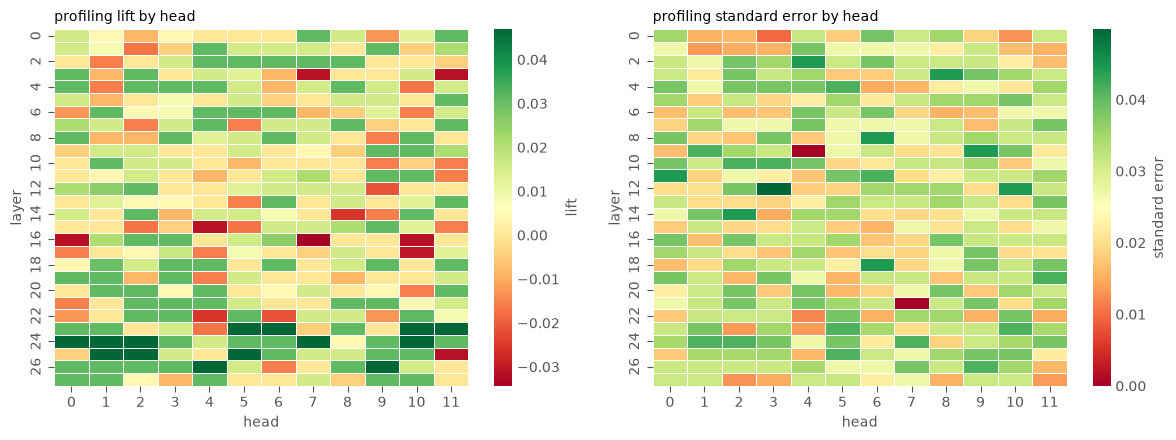

In [8]:
apply_plot_style()

lift_pivot = profile_frame.pivot(index="layer", columns="head", values="lift")
se_pivot = profile_frame.pivot(index="layer", columns="head", values="se")

fig, (ax_lift, ax_se) = plt.subplots(1, 2, figsize=(12.0, 4.5))
plot_metric_heatmap(
    lift_pivot,
    title="profiling lift by head",
    xlabel="head",
    ylabel="layer",
    annot=False,
    cbar_label="lift",
    col_label_decimals=None,
    ax=ax_lift,
)
plot_metric_heatmap(
    se_pivot,
    title="profiling standard error by head",
    xlabel="head",
    ylabel="layer",
    annot=False,
    cbar_label="standard error",
    col_label_decimals=None,
    ax=ax_se,
)
fig.tight_layout()
fig.savefig(PROFILE_DIR / "head_profile.png", dpi=150, bbox_inches="tight")
plt.show()

The selected heads are the top `HEAD_TOP_K` by lift, expressed in the dict form of `head_config` (layer index to head indices). The profile records how many candidates tie at the selection cutoff (a large tie means the cutoff is arbitrary at this profiling size) and how many selected heads beat the unsteered baseline. Before running the evaluation we release the profiling model, since `SteeringEval` builds its own pipeline per configuration and the reward model also shares the GPU.

In [9]:
selected_frame = profile_frame[profile_frame["selected"]].sort_values("rank")
above_baseline = int((selected_frame["lift"] > 0).sum())

profile_pipeline.release_backends()
for name in ("pasta", "profile_pipeline"):
    globals().pop(name, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

pd.Series({
    "selected heads": len(selected_frame),
    "layers covered": selected_frame["layer"].nunique(),
    "candidates tied at the cutoff": head_profile.tie_at_cutoff,
    "selected heads above the baseline": above_baseline,
}).to_frame("count")

,count
selected heads,41
layers covered,21
candidates tied at the cutoff,15
selected heads above the baseline,41


## Defining the control

We use `ControlSpec` to sweep PASTA's `alpha` over `ALPHAS`, fixing the profiled head configuration and the scale position in the `params` block. With `scale_position="include"` PASTA upweights attention onto the steered spans (the instruction lines) relative to the rest of the prompt. The sweep is centered on the paper's operating point, i.e., `alpha=100` corresponds to the paper's scaling coefficient of 0.01. The spec is named `PASTA`, which is the key the swept-parameter attachment uses later.

Note that `substrings` is not a constructor argument here. The task supplies each prompt's instruction lines per sample through the runtime kwargs, and the baseline arm ignores them because no control on that arm declares `substrings`. PASTA locates each span in the prompt by offset mapping and skips a span it cannot find (a small number of Split-IFEval prompts keep their original phrasing rather than the bulleted instruction line, so their span is skipped with a warning).


In [10]:
pasta_spec = ControlSpec(
    control_cls=PASTA,
    params={"head_config": PROFILED_HEAD_CONFIG, "scale_position": "include"},
    vars={"alpha": ALPHAS},
    name="PASTA",
)


## Running the evaluation

We evaluate the unsteered baseline and the PASTA `alpha` sweep. `SteeringEval` builds and steers each configuration once, then runs `NUM_TRIALS` trials against the `instruction_following` task. The model is loaded with `attn_implementation="eager"` because PASTA injects a 4D attention mask that only the eager and sdpa implementations consume; the pre-flight support check verifies this before any model loads. The model loads in bfloat16 through the same `HF_MODEL_KWARGS` as the profiling pipeline. Sampling is enabled through `temperature > 0` so trials vary, and the base seed keeps each (configuration, trial) reproducible. The per-trial frame is written to `runs.csv` so the figures can be rebuilt after a kernel restart, alongside Inspect's own log-level resume. Concurrent Inspect requests collate into batched pipeline calls of up to `EVAL_BATCH` rows; under seeded sampling a sample's continuation depends on its dispatch-mates, so the ceiling is part of the protocol. Note that `eval_set` resumes completed cells from the logs under `SAVE_DIR`, so we use a new `SAVE_DIR` when the protocol changes (the seed, generation defaults, provider options, or task).

In [11]:
runner = SteeringEval(
    pipelines={"baseline": [], "pasta_alpha_sweep": [pasta_spec]},
    base_model_name_or_path=MODEL_NAME,
    suites=[InspectSuite(
        name="ifeval",
        tasks=(TASK_REFERENCE,),
        task_args={
            "instruction_types": INSTRUCTION_TYPES,
            "per_type": PER_TYPE,
            "sample_seed": SAMPLE_SEED,
            "reward_model": REWARD_MODEL,
            "reward_max_length": REWARD_MAX_LENGTH,
        },
    )],
    hf_model_kwargs=HF_MODEL_KWARGS,
    num_trials=NUM_TRIALS,
    seed=SEED,
    generate_defaults={"temperature": TEMPERATURE, "max_tokens": MAX_TOKENS},
    provider_options=ProviderOptions(max_batch_size=EVAL_BATCH),
    save_dir=SAVE_DIR,
    display="none",
)
runner.run()

runs = runner.runs_frame(METRICS, params=SWEPT_PARAMS)
runs.to_csv(SAVE_DIR / "runs.csv", index=False)

steering eval:   0%|          | 0/50 [00:00<?, ?cell/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Output()

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Output()

...

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Output()

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Output()

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

## Analysis

We analyze the results across the sweep. The per-trial frame contains one row per (pipeline, trial) with the two headline metrics and the swept `alpha` value. The baseline rows contain `NaN` for `alpha`.

In [ ]:
runs[["pipeline", "trial_id", "alpha", "strict_prompt_acc", "mean_reward"]]

We aggregate the trials into a summary frame with `summarize_runs`, grouping by pipeline and configuration and carrying the swept `alpha` value through. Each metric gains `_mean`, `_std`, and `_sem` columns. We slice out the baseline and the sweep so the plots below can draw the baseline as a reference. We also apply the shared plot style here so the figures match the toolkit's scientific style.

In [ ]:
apply_plot_style()

summary = summarize_runs(
    runs,
    ["strict_prompt_acc", "mean_reward"],
    group_cols=["pipeline", "config_id"],
    param_cols=["alpha"],
)
baseline = summary[summary["pipeline"] == "baseline"]
swept = summary[summary["pipeline"] == "pasta_alpha_sweep"].sort_values("alpha")

summary[["pipeline", "alpha", "n_trials",
         "strict_prompt_acc_mean", "strict_prompt_acc_std",
         "mean_reward_mean", "mean_reward_std"]].round(3)

### Sensitivity to steering strength

We first look at how each metric responds to the steering strength. The left panel is the strict prompt-level accuracy and the right panel is the mean reward score, both against `alpha`, with the baseline drawn as a horizontal reference line via `compare_to_pipelines`. The grey scatter shows the per-trial values behind each swept point.

In [ ]:
figure_dir = SAVE_DIR / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

per_trial = runs[runs["pipeline"] == "pasta_alpha_sweep"]
references = [("baseline", baseline)]

fig = plt.figure(figsize=(10.0, 4.0))
grid = gridspec.GridSpec(1, 2, wspace=0.3)
plot_sensitivity(
    swept,
    metric="strict_prompt_acc",
    sweep_col="alpha",
    compare_to_pipelines=references,
    per_trial_data=per_trial,
    ax=fig.add_subplot(grid[0, 0]),
    metric_label="strict prompt accuracy",
    sweep_label="steering strength (alpha)",
    title="instruction following",
)
plot_sensitivity(
    swept,
    metric="mean_reward",
    sweep_col="alpha",
    compare_to_pipelines=references,
    per_trial_data=per_trial,
    ax=fig.add_subplot(grid[0, 1]),
    metric_label="mean reward score",
    sweep_label="steering strength (alpha)",
    title="response quality",
)
fig.savefig(figure_dir / "sensitivity.png", bbox_inches="tight", dpi=150)
plt.show()

### Instruction following vs quality tradeoff

We then examine the tradeoff between instruction following and response quality directly. The sweep configurations are colored by `alpha`, the baseline is drawn as a black X marker, and the Pareto frontier marks the configurations that are not dominated by any other (higher accuracy is better, higher reward is better).

In [ ]:
fig = plt.figure(figsize=(6.0, 5.0))
plot_tradeoff(
    swept,
    x_metric="strict_prompt_acc",
    y_metric="mean_reward",
    sweep_col="alpha",
    compare_to_pipelines=references,
    per_trial_data=per_trial,
    ax=fig.add_subplot(1, 1, 1),
    x_label="strict prompt accuracy",
    y_label="mean reward score",
    sweep_label="alpha",
    title="instruction following vs quality",
    show_pareto=True,
    maximize_x=True,
    maximize_y=True,
)
fig.savefig(figure_dir / "tradeoff.png", bbox_inches="tight", dpi=150)
plt.show()

## Per-instruction-type breakdown

The headline metrics average over all four instruction types. To see how steering acts on each type, we read the per-sample scores from the eval logs with `samples_frame`, which returns one row per (pipeline, trial, sample) with the per-sample strict-follow flag and reward joined to the sample metadata. We derive a short instruction type from the instruction id and place the baseline at `alpha = 0` for the breakdown only, since a heatmap needs one column per steering strength. Note that the baseline is not a zero-strength PASTA configuration; it is the unsteered arm.

In [ ]:
samples = runner.samples_frame(
    scores={"followed": "instruction_checker/prompt_level_strict", "reward": "reward_score"},
    metadata_keys=["instruction_id"],
    params=SWEPT_PARAMS,
    include_text=True,
)
samples["instruction_type"] = samples["instruction_id"].str.split(":").str[-1]
samples["alpha"] = samples["alpha"].fillna(0.0)
samples[["pipeline", "trial_id", "alpha", "instruction_type", "followed", "reward"]].head()

Averaging the per-sample flags over trials and samples gives a follow rate and a mean reward for each (instruction type, alpha) cell. The columns are sorted ascending so the baseline column (`alpha = 0`) comes first. The left panel is the follow rate on a shared zero-to-one scale and the right panel is the mean reward.

In [ ]:
follow_pivot = samples.pivot_table(
    index="instruction_type", columns="alpha", values="followed", aggfunc="mean",
).sort_index(axis=1)
reward_pivot = samples.pivot_table(
    index="instruction_type", columns="alpha", values="reward", aggfunc="mean",
).sort_index(axis=1)

fig = plt.figure(figsize=(12.0, 4.0))
grid = gridspec.GridSpec(1, 2, wspace=0.4)
plot_metric_heatmap(
    follow_pivot,
    ax=fig.add_subplot(grid[0, 0]),
    title="strict follow rate",
    xlabel="alpha (0 = baseline)",
    ylabel="instruction type",
    vmin=0.0,
    vmax=1.0,
    cbar_label="follow rate",
)
plot_metric_heatmap(
    reward_pivot,
    ax=fig.add_subplot(grid[0, 1]),
    title="mean reward",
    xlabel="alpha (0 = baseline)",
    ylabel="instruction type",
    fmt=".1f",
    cbar_label="reward",
)
fig.savefig(figure_dir / "heatmaps.png", bbox_inches="tight", dpi=150)
plt.show()

## Per-example comparison

We compare the baseline and the strongest steered configuration example by example. We average the per-sample follow flag and reward over trials for each (pipeline, configuration, sample), take the sweep configuration with the largest `alpha`, and join it to the baseline on the sample id. Averaging over trials rather than reading a single trial smooths out the sampling noise in each example. We label as "fixed" the examples the baseline fails (follow rate below 0.5) that the steered arm follows (follow rate at least 0.5), sorted by the reward change.

In [ ]:
per_example = (
    samples.groupby(["pipeline", "config_id", "sample_id"], as_index=False)
    .agg(followed=("followed", "mean"), reward=("reward", "mean"), alpha=("alpha", "first"))
)
strongest_alpha = per_example.loc[per_example["pipeline"] == "pasta_alpha_sweep", "alpha"].max()

baseline_examples = per_example[per_example["pipeline"] == "baseline"]
steered_examples = per_example[
    (per_example["pipeline"] == "pasta_alpha_sweep") & (per_example["alpha"] == strongest_alpha)
]
comparison = baseline_examples.merge(
    steered_examples, on="sample_id", suffixes=("_baseline", "_steered"),
)
comparison["reward_delta"] = comparison["reward_steered"] - comparison["reward_baseline"]

fixed = comparison[
    (comparison["followed_baseline"] < 0.5) & (comparison["followed_steered"] >= 0.5)
].sort_values("reward_delta", ascending=False)
fixed[["sample_id", "followed_baseline", "followed_steered",
       "reward_baseline", "reward_steered", "reward_delta"]].round(3)

For the first fixed example, we show the prompt and the trial-0 completions of both arms with their per-trial follow flag and reward, read from the per-sample frame. This shows what the steering changed in the response for a case where it turned a failure into a success.

In [ ]:
if not fixed.empty:
    example_id = fixed.iloc[0]["sample_id"]
    trial0 = samples[(samples["trial_id"] == 0) & (samples["sample_id"] == example_id)]

    prompt_text = trial0.iloc[0]["input"]
    print(prompt_text)

    for pipeline_name in ("baseline", "pasta_alpha_sweep"):
        arm_rows = trial0[trial0["pipeline"] == pipeline_name]
        if pipeline_name == "pasta_alpha_sweep":
            arm_rows = arm_rows[arm_rows["alpha"] == strongest_alpha]
        row = arm_rows.iloc[0]
        print(f"\n{pipeline_name} (followed={row['followed']:.0f}, reward={row['reward']:.2f}):")
        print(row["completion"])

### Summary table

The table below lists every configuration, sorted by pipeline and steering strength, and is also written to `summary.csv` next to the figures.

In [ ]:
summary = summary.sort_values(["pipeline", "alpha"], ignore_index=True)
summary.to_csv(figure_dir / "summary.csv", index=False)
summary.round(3)

## Takeaways

This notebook studied how post-hoc attention steering onto a prompt's instruction lines affects instruction following on single-instruction Split-IFEval prompts, following the two stages of the PASTA method. The profiling stage steered each attention head individually on a held-out slice and kept the top scoring heads, and the evaluation stage swept the steering strength over that head set, measuring strict instruction following against a reward-model quality score. The profiling heatmap shows how unevenly heads respond to steering, the sensitivity panels show how each metric responds to `alpha` relative to the unsteered baseline, and the tradeoff panel shows how the two move together as the steering strength increases. The per-instruction-type heatmaps show which instruction types the steering helps, and the per-example comparison shows individual prompts the steering turned from a failure into a success.
